In [6]:
import pandas as pd
import os

# Шлях до ваших сирих даних (змініть на свій, якщо він інший)
DATA_PATH = "C:/University/6 grade/Diploma/AniDB 2020/"

In [7]:
# 1. Завантаження файлів
# Припускаємо, що файли лежать у папці
df_anime = pd.read_csv(os.path.join(DATA_PATH, 'anime.csv'))
df_synopsis = pd.read_csv(os.path.join(DATA_PATH, 'anime_with_synopsis.csv'))

In [8]:
# 2. Огляд структури (перші кілька рядків)
print(f"Розмір основної таблиці: {df_anime.shape}")
print(f"Розмір таблиці з синопсисами: {df_synopsis.shape}")

Розмір основної таблиці: (17562, 35)
Розмір таблиці з синопсисами: (16214, 5)


In [9]:
# 3. Виведення назв колонок
print("Колонки df_anime:", df_anime.columns.tolist())
print("Колонки df_synopsis:", df_synopsis.columns.tolist())

Колонки df_anime: ['MAL_ID', 'Name', 'Score', 'Genres', 'English name', 'Japanese name', 'Type', 'Episodes', 'Aired', 'Premiered', 'Producers', 'Licensors', 'Studios', 'Source', 'Duration', 'Rating', 'Ranked', 'Popularity', 'Members', 'Favorites', 'Watching', 'Completed', 'On-Hold', 'Dropped', 'Plan to Watch', 'Score-10', 'Score-9', 'Score-8', 'Score-7', 'Score-6', 'Score-5', 'Score-4', 'Score-3', 'Score-2', 'Score-1']
Колонки df_synopsis: ['MAL_ID', 'Name', 'Score', 'Genres', 'sypnopsis']


In [10]:
# Перейменування колонки 'sypnopsis' на 'synopsis'
df_synopsis = df_synopsis.rename(columns={'sypnopsis': 'synopsis'})

In [11]:
print("Колонки df_synopsis:", df_synopsis.columns.tolist())

Колонки df_synopsis: ['MAL_ID', 'Name', 'Score', 'Genres', 'synopsis']


In [12]:
# 4. Перевірка пропусків та заглушок у колонці 'synopsis'
total_rows = len(df_synopsis)

# Заглушка 1
placeholder1 = "No synopsis has been added for this series yet. Click here to update this information."
count1 = (df_synopsis['synopsis'] == placeholder1).sum()
percent1 = (count1 / total_rows) * 100

# Заглушка 2
placeholder2 = "No synopsis information has been added to this title. Help improve our database by adding a synopsis here ."
count2 = (df_synopsis['synopsis'] == placeholder2).sum()
percent2 = (count2 / total_rows) * 100

# Пропуски (NaN)
nan_count = df_synopsis['synopsis'].isnull().sum()
nan_percent = (nan_count / total_rows) * 100

print(f"Заглушка 1: {count1} записів ({percent1:.2f}%)")
print(f"Заглушка 2: {count2} записів ({percent2:.2f}%)")
print(f"Пропуски: {nan_count} записів ({nan_percent:.2f}%)")

Заглушка 1: 35 записів (0.22%)
Заглушка 2: 709 записів (4.37%)
Пропуски: 8 записів (0.05%)


In [13]:
df_synopsis.loc[df_synopsis['synopsis'] == placeholder1, 'synopsis'] = None
df_synopsis.loc[df_synopsis['synopsis'] == placeholder2, 'synopsis'] = None

# Перевірка після заміни
nan_count_after = df_synopsis['synopsis'].isnull().sum()
nan_percent_after = (nan_count_after / total_rows) * 100

print(f"Пропуски після заміни: {nan_count_after} записів ({nan_percent_after:.2f}%)")

Пропуски після заміни: 752 записів (4.64%)


In [14]:
# 5. Перевірка співвідношення між df_anime та df_synopsis за MAL_ID
anime_ids = set(df_anime['MAL_ID'])
synopsis_ids = set(df_synopsis['MAL_ID'])

# Аніме у df_synopsis, але не у df_anime
only_in_synopsis = synopsis_ids - anime_ids
count_only_synopsis = len(only_in_synopsis)
percent_only_synopsis = (count_only_synopsis / len(synopsis_ids)) * 100

# Аніме у df_anime, але не у df_synopsis
only_in_anime = anime_ids - synopsis_ids
count_only_anime = len(only_in_anime)
percent_only_anime = (count_only_anime / len(anime_ids)) * 100

# Спільні аніме
common_ids = anime_ids & synopsis_ids
count_common = len(common_ids)

print(f"Всього у df_anime: {len(anime_ids)}")
print(f"Всього у df_synopsis: {len(synopsis_ids)}")
print(f"Спільних аніме: {count_common}")
print(f"\nТільки у df_synopsis: {count_only_synopsis} записів ({percent_only_synopsis:.2f}%)")
print(f"Тільки у df_anime: {count_only_anime} записів ({percent_only_anime:.2f}%)")

Всього у df_anime: 17562
Всього у df_synopsis: 16214
Спільних аніме: 16214

Тільки у df_synopsis: 0 записів (0.00%)
Тільки у df_anime: 1348 записів (7.68%)


In [15]:
# 6. Перевірка та видалення дуплікатів
anime_dup_count = df_anime.duplicated().sum()
synopsis_dup_count = df_synopsis.duplicated().sum()

print(f"Повні дуплікатні рядки в df_anime: {anime_dup_count}")
print(f"Повні дуплікатні рядки в df_synopsis: {synopsis_dup_count}")

df_anime = df_anime.drop_duplicates()
df_synopsis = df_synopsis.drop_duplicates()

print(f"Після видалення: df_anime = {len(df_anime)} рядків, df_synopsis = {len(df_synopsis)} рядків")

Повні дуплікатні рядки в df_anime: 0
Повні дуплікатні рядки в df_synopsis: 0
Після видалення: df_anime = 17562 рядків, df_synopsis = 16214 рядків


In [16]:
anime_dup_by_id = df_anime.duplicated(subset=['MAL_ID']).sum()
print(f"Дуплікатні MAL_ID в df_anime: {anime_dup_by_id}")

synopsis_dup_by_id = df_synopsis.duplicated(subset=['MAL_ID']).sum()
print(f"Дуплікатні MAL_ID в df_synopsis: {synopsis_dup_by_id}")

Дуплікатні MAL_ID в df_anime: 0
Дуплікатні MAL_ID в df_synopsis: 0


In [17]:
# 7. Перевірка збігу даних між df_anime та df_synopsis за MAL_ID
# Об'єднаємо датафрейми за MAL_ID
df_merged = pd.merge(df_synopsis[['MAL_ID', 'Name', 'Score', 'Genres']], 
                      df_anime[['MAL_ID', 'Name', 'Score', 'Genres']], 
                      on='MAL_ID', 
                      suffixes=('_synopsis', '_anime'),
                      how='inner')

# Перевіримо, чи збігаються значення
name_mismatch = (df_merged['Name_synopsis'] != df_merged['Name_anime']).sum()
score_mismatch = (df_merged['Score_synopsis'] != df_merged['Score_anime']).sum()
genres_mismatch = (df_merged['Genres_synopsis'] != df_merged['Genres_anime']).sum()

print(f"Розбіжності в Name: {name_mismatch} записів")
print(f"Розбіжності в Score: {score_mismatch} записів")
print(f"Розбіжності в Genres: {genres_mismatch} записів")

# Виведемо приклади розбіжностей для Name
if name_mismatch > 0:
    print("\nПриклади розбіжностей в Name:")
    print(df_merged[df_merged['Name_synopsis'] != df_merged['Name_anime']][['MAL_ID', 'Name_synopsis', 'Name_anime']].head())

# Виведемо приклади розбіжностей для Score
if score_mismatch > 0:
    print("\nПриклади розбіжностей в Score:")
    print(df_merged[df_merged['Score_synopsis'] != df_merged['Score_anime']][['MAL_ID', 'Score_synopsis', 'Score_anime']].head())

# Виведемо приклади розбіжностей для Genres
if genres_mismatch > 0:
    print("\nПриклади розбіжностей в Genres:")
    print(df_merged[df_merged['Genres_synopsis'] != df_merged['Genres_anime']][['MAL_ID', 'Genres_synopsis', 'Genres_anime']].head())

Розбіжності в Name: 0 записів
Розбіжності в Score: 0 записів
Розбіжності в Genres: 0 записів


In [18]:
# 8. Додавання синопсисів до df_anime
# Створимо словник MAL_ID -> synopsis з df_synopsis
synopsis_dict = dict(zip(df_synopsis['MAL_ID'], df_synopsis['synopsis']))

# Додамо нову колонку з синопсисами (NaN для аніме, яких нема в df_synopsis)
df_anime['synopsis'] = df_anime['MAL_ID'].map(synopsis_dict)

# Перевірка кількості NaN у синопсисах
total_anime = len(df_anime)
nan_count_synopsis = df_anime['synopsis'].isnull().sum()
nan_percent_synopsis = (nan_count_synopsis / total_anime) * 100

print(f"Всього аніме в df_anime: {total_anime}")
print(f"NaN у колонці synopsis: {nan_count_synopsis} записів ({nan_percent_synopsis:.2f}%)")
print(f"З синопсисами: {total_anime - nan_count_synopsis} записів ({100 - nan_percent_synopsis:.2f}%)")

Всього аніме в df_anime: 17562
NaN у колонці synopsis: 2100 записів (11.96%)
З синопсисами: 15462 записів (88.04%)


In [19]:
# 9. Перевірка кількості "Unknown" у колонках імен
name_columns = ['Name', 'English name', 'Japanese name']

print("Перевірка 'Unknown' значень у колонках імен:")
for col in name_columns:
    if col in df_anime.columns:
        unknown_count = (df_anime[col] == 'Unknown').sum()
        unknown_percent = (unknown_count / len(df_anime)) * 100
        nan_count = df_anime[col].isnull().sum()
        nan_percent = (nan_count / len(df_anime)) * 100
        
        print(f"\n{col}:")
        print(f"  Unknown: {unknown_count} записів ({unknown_percent:.2f}%)")
        print(f"  NaN: {nan_count} записів ({nan_percent:.2f}%)")
    else:
        print(f"\n{col}: колонка не знайдена")

Перевірка 'Unknown' значень у колонках імен:

Name:
  Unknown: 0 записів (0.00%)
  NaN: 0 записів (0.00%)

English name:
  Unknown: 10565 записів (60.16%)
  NaN: 0 записів (0.00%)

Japanese name:
  Unknown: 48 записів (0.27%)
  NaN: 0 записів (0.00%)


In [20]:
# 10. Замінити Unknown на NaN у колонці 'English name'
print("Заміна 'Unknown' на NaN у колонці 'English name':")

# Замінити 'Unknown' на None (NaN)
df_anime.loc[df_anime['English name'] == 'Unknown', 'English name'] = None

# Перевірка після заміни
nan_count_after = df_anime['English name'].isnull().sum()
nan_percent_after = (nan_count_after / len(df_anime)) * 100

print(f"NaN після заміни: {nan_count_after} записів ({nan_percent_after:.2f}%)")

Заміна 'Unknown' на NaN у колонці 'English name':
NaN після заміни: 10565 записів (60.16%)


In [21]:
# 11а. Дослідження колонки Score перед конвертацією
print("=== ДОСЛІДЖЕННЯ КОЛОНКИ SCORE ===\n")

# Перевіримо тип даних
print(f"Тип даних: {df_anime['Score'].dtype}")
print(f"Всього записів: {len(df_anime)}\n")

# Подивимось на унікальні значення
print("Кількість унікальних значень:", df_anime['Score'].nunique())
print("\nПерші 20 унікальних значень:")
print(df_anime['Score'].unique()[:20])

# Перевіримо на NaN ДО конвертації
nan_before = df_anime['Score'].isnull().sum()
print(f"\nNaN ДО конвертації: {nan_before} записів")

# Перевіримо на пропуски/порожні рядки
empty_count = (df_anime['Score'] == '').sum()
print(f"Порожні рядки (''):  {empty_count} записів")

# Перевіримо на 'N/A', 'None', тощо
print("\nПоширені значення, які можуть викликати NaN:")
for val in ['N/A', 'None', 'unknown', '-', ' ', 'NA']:
    count = (df_anime['Score'] == val).sum()
    if count > 0:
        print(f"  '{val}': {count} записів")

# Подивимось на значення, які НЕ можна конвертувати в числа
print("\nПриклади значень, які НЕ можна конвертувати:")
test_conversion = pd.to_numeric(df_anime['Score'], errors='coerce')
invalid_mask = test_conversion.isnull() & df_anime['Score'].notna()
invalid_values = df_anime.loc[invalid_mask, 'Score'].unique()
print(invalid_values[:20])
print(f"Всього таких значень: {invalid_mask.sum()}")

=== ДОСЛІДЖЕННЯ КОЛОНКИ SCORE ===

Тип даних: object
Всього записів: 17562

Кількість унікальних значень: 533

Перші 20 унікальних значень:
['8.78' '8.39' '8.24' '7.27' '6.98' '7.95' '8.06' '7.59' '8.15' '8.76'
 '7.91' '8.52' '7.9' '6.38' '7.94' '7.42' '7.76' '7.32' '7.51' '8.32']

NaN ДО конвертації: 0 записів
Порожні рядки (''):  0 записів

Поширені значення, які можуть викликати NaN:

Приклади значень, які НЕ можна конвертувати:
['Unknown']
Всього таких значень: 5141


In [22]:
# 11б. Дослідження аніме з Unknown Score
print("=== ДОСЛІДЖЕННЯ АНІМЕ З UNKNOWN SCORE ===\n")

# Знайдемо рядки з Unknown Score
unknown_score_mask = df_anime['Score'] == 'Unknown'
unknown_score_count = unknown_score_mask.sum()

print(f"Всього аніме з Unknown Score: {unknown_score_count}\n")

# Виведемо перші 10 аніме з Unknown Score та їх деталі
print("Деталі першого аніме з Unknown Score:\n")
unknown_anime_indices = df_anime[unknown_score_mask].index[:10]

for idx in unknown_anime_indices:
    anime = df_anime.loc[idx]
    print(f"MAL_ID: {anime['MAL_ID']} | Name: {anime['Name']}")
    print(f"  Score: {anime['Score']}")
    print(f"  Ranked: {anime['Ranked']}")
    print(f"  Score-10: {anime['Score-10']}")
    print(f"  Score-9: {anime['Score-9']}")
    print(f"  Score-8: {anime['Score-8']}")
    print(f"  Score-7: {anime['Score-7']}")
    print(f"  Score-6: {anime['Score-6']}")
    print(f"  Score-5: {anime['Score-5']}")
    print(f"  Score-4: {anime['Score-4']}")
    print(f"  Score-3: {anime['Score-3']}")
    print(f"  Score-2: {anime['Score-2']}")
    print(f"  Score-1: {anime['Score-1']}")
    print()

=== ДОСЛІДЖЕННЯ АНІМЕ З UNKNOWN SCORE ===

Всього аніме з Unknown Score: 5141

Деталі першого аніме з Unknown Score:

MAL_ID: 1547 | Name: Obake no Q-tarou
  Score: Unknown
  Ranked: 11270.0
  Score-10: 8.0
  Score-9: 5.0
  Score-8: 6.0
  Score-7: 20.0
  Score-6: 28.0
  Score-5: 31.0
  Score-4: 6.0
  Score-3: 6.0
  Score-2: 2.0
  Score-1: 10.0

MAL_ID: 1656 | Name: PostPet Momobin
  Score: Unknown
  Ranked: 11598.0
  Score-10: 7.0
  Score-9: 2.0
  Score-8: 6.0
  Score-7: 13.0
  Score-6: 17.0
  Score-5: 22.0
  Score-4: 15.0
  Score-3: 12.0
  Score-2: 7.0
  Score-1: 10.0

MAL_ID: 1739 | Name: Shibawanko no Wa no Kokoro
  Score: Unknown
  Ranked: 11947.0
  Score-10: 6.0
  Score-9: 4.0
  Score-8: 23.0
  Score-7: 28.0
  Score-6: 18.0
  Score-5: 17.0
  Score-4: 1.0
  Score-3: 3.0
  Score-2: Unknown
  Score-1: 8.0

MAL_ID: 1863 | Name: Silk Road Shounen Yuuto
  Score: Unknown
  Ranked: 12096.0
  Score-10: 3.0
  Score-9: 1.0
  Score-8: 2.0
  Score-7: 9.0
  Score-6: 5.0
  Score-5: 9.0
  Score-4

Аналіз розподілу оцінок (Score):

Оцінки 0: 0 записів (0.00%)
Unknown/NaN: 5141 записів (29.27%)
Дійсних оцінок (1-10): 12421 записів (70.73%)

Розподіл оцінок за діапазонами:
  (0, 1]: 0 записів (0.00% від валідних, 0.00% від всіх)
  (1, 2]: 1 записів (0.01% від валідних, 0.01% від всіх)
  (2, 3]: 12 записів (0.10% від валідних, 0.07% від всіх)
  (3, 4]: 48 записів (0.39% від валідних, 0.27% від всіх)
  (4, 5]: 452 записів (3.64% від валідних, 2.57% від всіх)
  (5, 6]: 2880 записів (23.19% від валідних, 16.40% від всіх)
  (6, 7]: 5284 записів (42.54% від валідних, 30.09% від всіх)
  (7, 8]: 3211 записів (25.85% від валідних, 18.28% від всіх)
  (8, 9]: 524 записів (4.22% від валідних, 2.98% від всіх)
  (9, 10]: 9 записів (0.07% від валідних, 0.05% від всіх)


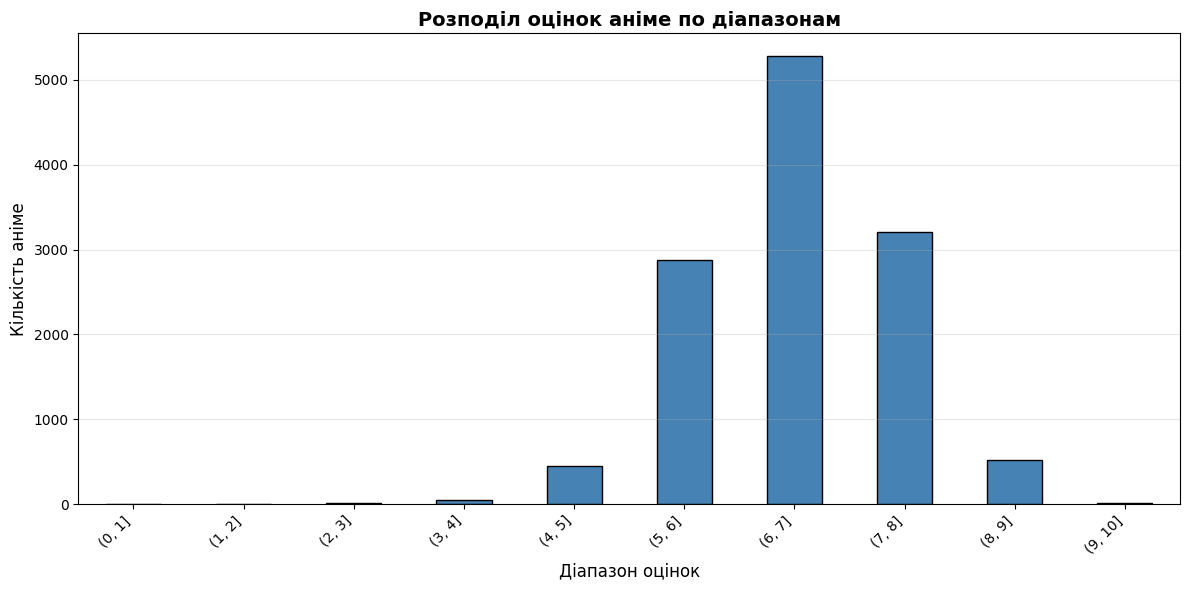

In [23]:
# 11. Аналіз розподілу оцінок (Score)
import matplotlib.pyplot as plt
import numpy as np

print("Аналіз розподілу оцінок (Score):")

# Замінити 'Unknown' на NaN перед конвертацією
df_anime['Score'] = df_anime['Score'].replace('Unknown', np.nan)

# Конвертуємо Score в float
df_anime['Score'] = pd.to_numeric(df_anime['Score'], errors='coerce')

total_anime = len(df_anime)

# Перевірка на 0 та Unknown значення
zero_count = (df_anime['Score'] == 0).sum()
zero_percent = (zero_count / total_anime) * 100

unknown_count = df_anime['Score'].isnull().sum()
unknown_percent = (unknown_count / total_anime) * 100

print(f"\nОцінки 0: {zero_count} записів ({zero_percent:.2f}%)")
print(f"Unknown/NaN: {unknown_count} записів ({unknown_percent:.2f}%)")

# Фільтруємо оцінки від 1 до 10
valid_scores = df_anime[(df_anime['Score'] > 0) & (df_anime['Score'] <= 10)]['Score']
valid_count = len(valid_scores)
valid_percent = (valid_count / total_anime) * 100

print(f"Дійсних оцінок (1-10): {valid_count} записів ({valid_percent:.2f}%)")

# Розбиваємо на 10 діапазонів
bins = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
labels = ['(0, 1]', '(1, 2]', '(2, 3]', '(3, 4]', '(4, 5]', '(5, 6]', '(6, 7]', '(7, 8]', '(8, 9]', '(9, 10]']

score_distribution = pd.cut(valid_scores, bins=bins, labels=labels, right=True)
score_counts = score_distribution.value_counts().sort_index()

print("\nРозподіл оцінок за діапазонами:")
for label, count in score_counts.items():
    percent_range = (count / valid_count) * 100
    percent_total = (count / total_anime) * 100
    print(f"  {label}: {count} записів ({percent_range:.2f}% від валідних, {percent_total:.2f}% від всіх)")

# Побудова діаграми
plt.figure(figsize=(12, 6))
score_counts.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Розподіл оцінок аніме по діапазонам', fontsize=14, fontweight='bold')
plt.xlabel('Діапазон оцінок', fontsize=12)
plt.ylabel('Кількість аніме', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [24]:
# 12. Конвертація Ranked та колонок Score-* у числовий формат
print("Конвертація Ranked та колонок Score-* у числовий формат:")

# Перетворюємо Ranked на числа. Помилки (Unknown) стануть NaN.
df_anime['Ranked'] = pd.to_numeric(df_anime['Ranked'], errors='coerce')

# Перетворюємо колонки Score-1...10 на числа
score_cols = [f'Score-{i}' for i in range(1, 11)]
for col in score_cols:
    df_anime[col] = pd.to_numeric(df_anime[col], errors='coerce')

print("Конвертація завершена.\n")

Конвертація Ranked та колонок Score-* у числовий формат:
Конвертація завершена.



In [25]:
# 13. Аналіз зв'язків між Score та Ranked
print("Аналіз зв'язків між Score та Ranked:")

total_anime = len(df_anime)

# Перевірка: скільки Unknown Score мають відомий Ranked?
missing_score_with_rank = df_anime[df_anime['Score'].isnull() & df_anime['Ranked'].notnull()].shape[0]
missing_score_with_rank_percent = (missing_score_with_rank / total_anime) * 100
print(f"Кількість аніме без Score, але з відомим Ranked: {missing_score_with_rank} записів ({missing_score_with_rank_percent:.2f}%)")

# Перевірка: скільки Ranked Unknown
ranked_unknown_count = df_anime[df_anime['Ranked'].isnull()].shape[0]
ranked_unknown_percent = (ranked_unknown_count / total_anime) * 100
print(f"Кількість аніме з Unknown Ranked: {ranked_unknown_count} записів ({ranked_unknown_percent:.2f}%)")

# Перевірка: скільки Unknown Ranked мають відомий Score
ranked_unknown_with_score = df_anime[df_anime['Ranked'].isnull() & df_anime['Score'].notnull()].shape[0]
ranked_unknown_with_score_percent = (ranked_unknown_with_score / total_anime) * 100
print(f"Кількість аніме з Unknown Ranked, але відомим Score: {ranked_unknown_with_score} записів ({ranked_unknown_with_score_percent:.2f}%)")

# Перевірка: скільки аніме мають і Unknown Score, і Unknown Ranked
both_unknown_count = df_anime[df_anime['Score'].isnull() & df_anime['Ranked'].isnull()].shape[0]
both_unknown_percent = (both_unknown_count / total_anime) * 100
print(f"Кількість аніме з Unknown Score та Unknown Ranked: {both_unknown_count} записів ({both_unknown_percent:.2f}%)")

Аналіз зв'язків між Score та Ranked:
Кількість аніме без Score, але з відомим Ranked: 4737 записів (26.97%)
Кількість аніме з Unknown Ranked: 1762 записів (10.03%)
Кількість аніме з Unknown Ranked, але відомим Score: 1358 записів (7.73%)
Кількість аніме з Unknown Score та Unknown Ranked: 404 записів (2.30%)


In [26]:
# 14. Перевірка кількості Unknown/NaN у колонках Score-*
print("Перевірка кількості Unknown/NaN у колонках Score-*:")

score_cols = [f'Score-{i}' for i in range(1, 11)]
total_anime = len(df_anime)

for col in score_cols:
    if col in df_anime.columns:
        unknown_count = df_anime[col].isnull().sum()
        unknown_percent = (unknown_count / total_anime) * 100
        print(f"{col}: {unknown_count} записів ({unknown_percent:.2f}%)")
    else:
        print(f"{col}: колонка не знайдена")

Перевірка кількості Unknown/NaN у колонках Score-*:
Score-1: 459 записів (2.61%)
Score-2: 1597 записів (9.09%)
Score-3: 1307 записів (7.44%)
Score-4: 977 записів (5.56%)
Score-5: 584 записів (3.33%)
Score-6: 511 записів (2.91%)
Score-7: 503 записів (2.86%)
Score-8: 1371 записів (7.81%)
Score-9: 3167 записів (18.03%)
Score-10: 437 записів (2.49%)


In [27]:
# 15. Перевірка кількості аніме з 2+ невідомими Score-*
print("Перевірка кількості аніме з 2+ невідомими Score-*:")

score_cols = [f'Score-{i}' for i in range(1, 11)]
total_anime = len(df_anime)

# Підрахуємо кількість NaN в Score-* для кожного аніме
nan_counts = df_anime[score_cols].isnull().sum(axis=1)

# Аніме з 2+ NaN
two_or_more_nan = (nan_counts >= 2).sum()
two_or_more_percent = (two_or_more_nan / total_anime) * 100

print(f"Аніме з 2+ невідомими Score-*: {two_or_more_nan} записів ({two_or_more_percent:.2f}%)")

# Додатково: розподіл кількості NaN
print("\nРозподіл кількості невідомих Score-* на аніме:")
for i in range(11):
    count = (nan_counts == i).sum()
    if count > 0:
        percent = (count / total_anime) * 100
        print(f"  {i} невідомих: {count} записів ({percent:.2f}%)")

Перевірка кількості аніме з 2+ невідомими Score-*:
Аніме з 2+ невідомими Score-*: 2167 записів (12.34%)

Розподіл кількості невідомих Score-* на аніме:
  0 невідомих: 13436 записів (76.51%)
  1 невідомих: 1959 записів (11.15%)
  2 невідомих: 889 записів (5.06%)
  3 невідомих: 427 записів (2.43%)
  4 невідомих: 243 записів (1.38%)
  5 невідомих: 134 записів (0.76%)
  6 невідомих: 71 записів (0.40%)
  7 невідомих: 40 записів (0.23%)
  8 невідомих: 17 записів (0.10%)
  9 невідомих: 49 записів (0.28%)
  10 невідомих: 297 записів (1.69%)


In [28]:
# 16. Функції для розрахунку оцінок

def estimate_methods(df, target_idx):
    """
    Розраховує оцінку трьома методами для аніме з відсутнім Score.
    """
    target_rank = df.loc[target_idx, 'Ranked']
    
    # --- Метод 1: Інтерполяція за сусідніми рангами ---
    # Шукаємо аніме з рангом n-1 та n+1
    prev_score = df[df['Ranked'] == target_rank - 1]['Score'].values
    next_score = df[df['Ranked'] == target_rank + 1]['Score'].values
    
    m1 = np.nan
    if len(prev_score) > 0 and len(next_score) > 0:
        m1 = (prev_score[0] + next_score[0]) / 2

    # --- Метод 2: Зважене середнє голосів ---
    # Формула: (1*S1 + 2*S2 + ... + 10*S10) / (S1 + S2 + ... + S10)
    counts = df.loc[target_idx, score_cols].values
    weights = np.arange(1, 11)
    
    m2 = np.nan
    if np.nansum(counts) > 0:
        m2 = np.nansum(counts * weights) / np.nansum(counts)

    # --- Метод 3: Середнє арифметичне ---
    m3 = np.nan
    if not np.isnan(m1) and not np.isnan(m2):
        m3 = (m1 + m2) / 2
        
    return m1, m2, m3

print("Функції для розрахунку оцінок визначені.")

Функції для розрахунку оцінок визначені.


In [29]:
# Тестування на 10 рандомних аніме
print("Тестування методів на 10 випадкових аніме з повними даними:")

# Вибираємо дані, де все відомо (Score, Ranked та всі Score-X не NaN)
test_pool = df_anime.dropna(subset=['Score', 'Ranked'] + score_cols)
samples = test_pool.sample(10, random_state=42)  # random_state для відтворення результату

results = []

for idx in samples.index:
    real_score = samples.loc[idx, 'Score']
    name = samples.loc[idx, 'Name']
    m1, m2, m3 = estimate_methods(df_anime, idx)
    
    results.append({
        'Name': name[:30],
        'Real': real_score,
        'M1 (Rank)': round(m1, 2) if not np.isnan(m1) else None,
        'M2 (Votes)': round(m2, 2) if not np.isnan(m2) else None,
        'M3 (Hybrid)': round(m3, 2) if not np.isnan(m3) else None,
        'Error M3': round(abs(real_score - m3), 3) if not np.isnan(m3) else None
    })

# Виводимо таблицю результатів
res_df = pd.DataFrame(results)
print(res_df.to_string(index=False))

mae = res_df['Error M3'].dropna().mean()
print(f"\nСередня абсолютна помилка (MAE) для Метод 3: {mae:.4f}")

Тестування методів на 10 випадкових аніме з повними даними:
                          Name  Real  M1 (Rank)  M2 (Votes)  M3 (Hybrid)  Error M3
            100% Pascal-sensei  5.60       5.60        5.14         5.37     0.229
                  SSSS.Gridman  7.19        NaN        7.13          NaN       NaN
                      Kujakuou  5.95       5.95        5.94         5.94     0.007
    Dororon Enma-kun Meeramera  6.53        NaN        6.41          NaN       NaN
                        Tarzan  5.34       5.35        4.76         5.06     0.283
               Haru no Shikumi  4.53       4.48        4.10         4.29     0.238
                   Yuukan Club  5.86        NaN        5.74          NaN       NaN
Paniponi Dash!: Danjite Okonae  7.51        NaN        7.54          NaN       NaN
                   Youjo Senki  8.00        NaN        7.96          NaN       NaN
              Marriage: Kekkon  5.43        NaN        5.25          NaN       NaN

Середня абсолютна помилка 

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Отримуємо всі дійсні ранги
existing_ranks = df_anime['Ranked'].dropna().sort_values().unique()
max_rank = int(existing_ranks.max())
full_range = set(range(1, max_rank + 1))

# 2. Знаходимо "дірки" в нумерації
missing_in_sequence = full_range - set(existing_ranks)

print(f"Максимальний ранг у базі: {max_rank}")
print(f"Кількість аніме в базі: {len(df_anime)}")
print(f"Кількість 'дірок' у самій послідовності рангів: {len(missing_in_sequence)}")

if len(missing_in_sequence) > 0:
    print(f"Перші 10 пропущених номерів рангів: {sorted(list(missing_in_sequence))[:10]}")

Максимальний ранг у базі: 15780
Кількість аніме в базі: 17562
Кількість 'дірок' у самій послідовності рангів: 5292
Перші 10 пропущених номерів рангів: [8, 14, 24, 41, 48, 58, 66, 72, 73, 83]


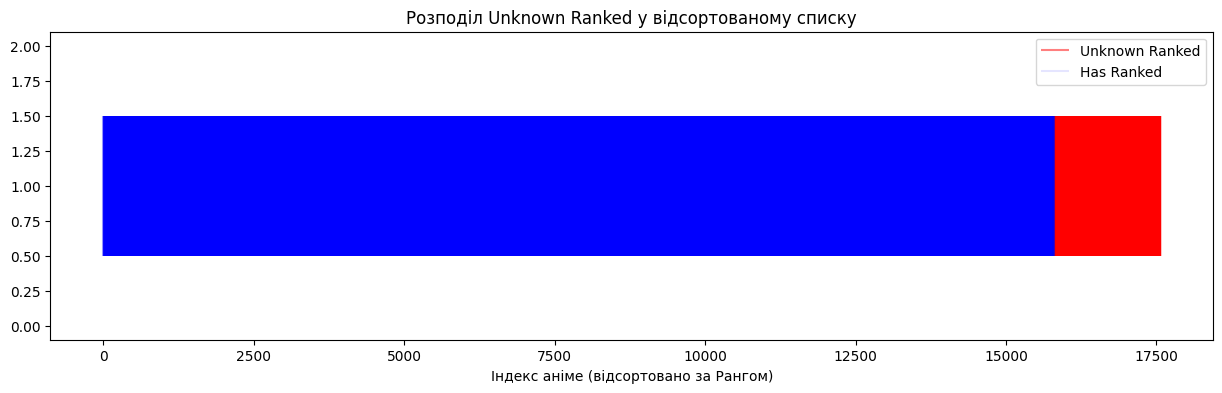

In [34]:
# Створимо копію для візуалізації, відсортовану за рангом
df_sorted = df_anime.copy()
# Для аніме без рангу присвоїмо значення вище максимального, щоб побачити їх в кінці
df_sorted['Ranked_Viz'] = df_sorted['Ranked'].fillna(max_rank + 500)
df_sorted = df_sorted.sort_values('Ranked_Viz').reset_index()

plt.figure(figsize=(15, 4))
# Візуалізуємо наявність рангу як "штрих-код"
plt.eventplot(df_sorted[df_sorted['Ranked'].isnull()].index, color='red', alpha=0.5, label='Unknown Ranked')
plt.eventplot(df_sorted[df_sorted['Ranked'].notnull()].index, color='blue', alpha=0.1, label='Has Ranked')

plt.title('Розподіл Unknown Ranked у відсортованому списку')
plt.xlabel('Індекс аніме (відсортовано за Рангом)')
plt.legend()
plt.show()

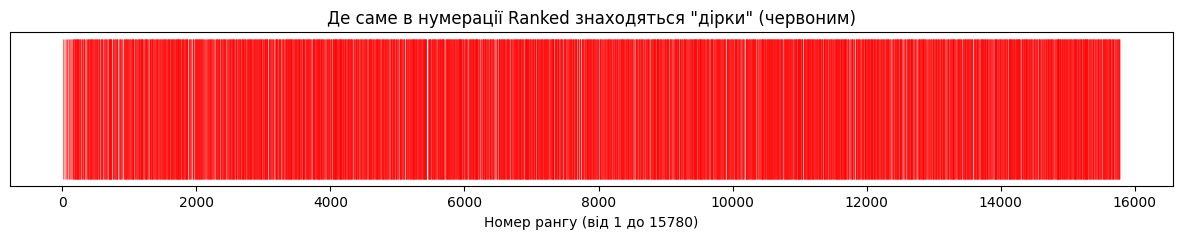

In [36]:
import matplotlib.pyplot as plt

# Створимо список усіх можливих рангів від 1 до Макс
all_possible_ranks = pd.DataFrame({'rank_id': range(1, int(df_anime['Ranked'].max()) + 1)})

# Перевіримо, які з них є в нашому df
all_possible_ranks['exists'] = all_possible_ranks['rank_id'].isin(df_anime['Ranked'])

plt.figure(figsize=(15, 2))
# Малюємо вертикальні лінії тільки там, де ранг ІСНУЄ
plt.vlines(x=all_possible_ranks[all_possible_ranks['exists'] == False]['rank_id'], 
           ymin=0, ymax=1, color='red', alpha=0.5, linewidth=0.5)

plt.title('Де саме в нумерації Ranked знаходяться "дірки" (червоним)')
plt.xlabel('Номер рангу (від 1 до 15780)')
plt.yticks([]) # прибираємо вісь Y
plt.show()

In [38]:
# Рахуємо, скільки разів зустрічається кожен номер рангу
rank_counts = df_anime['Ranked'].value_counts()

# Виводимо ранги, які мають найбільше дублікатів
print("Ранги, які повторюються найчастіше:")
print(rank_counts[rank_counts > 1].head(10))

# Скільки всього аніме мають «не унікальний» ранг?
duplicated_ranks_count = df_anime.duplicated(subset=['Ranked'], keep=False) & df_anime['Ranked'].notnull()
print(f"\nКількість аніме з дубльованими рангами: {duplicated_ranks_count.sum()}")

Ранги, які повторюються найчастіше:
Ranked
5297.0     6
12978.0    6
11436.0    5
14687.0    5
9637.0     5
6170.0     5
5919.0     5
5946.0     5
3251.0     5
11558.0    5
Name: count, dtype: int64

Кількість аніме з дубльованими рангами: 9396


In [39]:
# 1. Беремо лише ті записи, де є і Score, і Ranked
df_check = df_anime.dropna(subset=['Score', 'Ranked']).copy()

# 2. Групуємо за рангом і рахуємо кількість унікальних значень Score
rank_variance = df_check.groupby('Ranked')['Score'].nunique()

# 3. Виводимо ранги, де більше одного унікального Score
multi_score_ranks = rank_variance[rank_variance > 1]

print(f"Кількість рангів з кількома різними оцінками: {len(multi_score_ranks)}")
if len(multi_score_ranks) > 0:
    print("Приклади рангів з різними Score:")
    example_rank = multi_score_ranks.index[0]
    print(df_check[df_check['Ranked'] == example_rank][['Name', 'Score', 'Ranked']])
else:
    print("Гіпотеза підтверджена: Кожен ранг відповідає одному унікальному значенню Score.")

Кількість рангів з кількома різними оцінками: 612
Приклади рангів з різними Score:
                      Name  Score  Ranked
741   Ginga Eiyuu Densetsu   9.07     7.0
6006              Gintama'   9.08     7.0


In [51]:
# 1. Рахуємо різницю між макс і мін Score для кожного рангу
score_diffs = df_check.groupby('Ranked')['Score'].agg(lambda x: x.max() - x.min())

# 2. Фільтруємо лише ті, де є різниця > 0
varying_ranks = score_diffs[score_diffs > 0]

print(f"Статистика розбіжностей Score всередині одного рангу:")
print(varying_ranks.describe())

print(f"\nМаксимальна розбіжність: {varying_ranks.max():.4f}")
print(f"Середня розбіжність: {varying_ranks.mean():.4f}")

# Подивимось на ранг з найбільшою помилкою
max_diff_rank = varying_ranks.idxmax()
print(f"\nНайбільша розбіжність у рангу {max_diff_rank}:")
print(df_check[df_check['Ranked'] == max_diff_rank][['Name', 'Score']])

Статистика розбіжностей Score всередині одного рангу:
count    612.000000
mean       0.027435
std        0.083257
min        0.010000
25%        0.010000
50%        0.010000
75%        0.010000
max        0.970000
Name: Score, dtype: float64

Максимальна розбіжність: 0.9700
Середня розбіжність: 0.0274

Найбільша розбіжність у рангу 11047.0:
              Name  Score
8612   Scrap Diary   3.32
10253         Nami   2.35
10270          001   3.27


In [57]:
# 1. Знаходимо найближчі існуючі ранги до 11047
prev_ranks = df_anime[df_anime['Ranked'] < 11047]['Ranked'].sort_values(ascending=False).unique()[:2]
next_ranks = df_anime[df_anime ['Ranked'] > 11047]['Ranked'].sort_values(ascending=True).unique()[:2]

print(f"Сусіди рангу 11047.0:")
print(f"Попередні: {prev_ranks}")
print(f"Наступні: {next_ranks}")

# 2. Перевіряємо очікуваний наступний ранг
# Ранг 11047 мають 3 аніме, отже наступний має бути 11047 + 3 = 11050
expected_next = 11047 + 3
print(f"\nОчікуваний наступний ранг: {expected_next}")

# 3. Шукаємо аніме БЕЗ рангу, але з оцінками в діапазоні [2.35, 3.32]
candidates = df_anime[df_anime['Ranked'].isna() & df_anime['Score'].between(2.35, 3.32)]
print(f"\nКількість аніме без рангу з оцінкою 2.35-3.32: {len(candidates)}")
if len(candidates) > 0:
    print("Приклади кандидатів:")
    print(candidates[['Name', 'Score', 'Genres']].head(5))

Сусіди рангу 11047.0:
Попередні: [11046. 11045.]
Наступні: [11048. 11049.]

Очікуваний наступний ранг: 11050

Кількість аніме без рангу з оцінкою 2.35-3.32: 0


In [58]:
# Перевірка оцінок сусідів для виявлення розриву (cliff)
neighbors_scores = df_anime[df_anime['Ranked'].isin([11046, 11048])][['Ranked', 'Score']]
print(neighbors_scores.groupby('Ranked')['Score'].mean())

Ranked
11046.0    3.083333
11048.0    3.380000
Name: Score, dtype: float64


In [65]:
# Рахуємо різницю Score для кожного рангу
rank_diffs = df_anime.dropna(subset=['Score', 'Ranked']).groupby('Ranked')['Score'].agg(lambda x: x.max() - x.min())

# Знаходимо аномалії
big_anomalies = rank_diffs[rank_diffs > 0.5]

print(f"Кількість рангів з розбіжністю Score > 0.5: {len(big_anomalies)}")
if len(big_anomalies) > 0:
    print("\nЦі ранги та їх максимальна розбіжність:")
    print(big_anomalies)

Кількість рангів з розбіжністю Score > 0.5: 6

Ці ранги та їх максимальна розбіжність:
Ranked
11016.0    0.62
11026.0    0.65
11028.0    0.66
11041.0    0.84
11046.0    0.62
11047.0    0.97
Name: Score, dtype: float64


In [69]:
# Перевіримо кореляцію (має бути від'ємною: чим більший ранг, тим менша оцінка)
correlation = df_anime['Ranked'].corr(df_anime['Score'])
print(f"Глобальна кореляція Ranked та Score: {correlation:.4f}")

# Подивимось на середні оцінки в різних діапазонах рангів
print("\nСередній Score за діапазонами рангів:")
ranges = [0, 100, 1000, 5000, 10000, 15000, 15780]
print(df_anime.groupby(pd.cut(df_anime['Ranked'], bins=ranges))['Score'].mean())

Глобальна кореляція Ranked та Score: -0.9730

Середній Score за діапазонами рангів:
Ranked
(0, 100]          8.716139
(100, 1000]       8.019356
(1000, 5000]      7.153566
(5000, 10000]     6.120719
(10000, 15000]    4.902439
(15000, 15780]         NaN
Name: Score, dtype: float64


C:\Users\Anton\AppData\Local\Temp\ipykernel_22176\505082930.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_anime.groupby(pd.cut(df_anime['Ranked'], bins=ranges))['Score'].mean())


In [70]:
# Перевіримо останній сегмент рангів
tail_check = df_anime[df_anime['Ranked'] > 15000]
print(f"Кількість аніме з рангом > 15000: {len(tail_check)}")
print(f"З них мають відомий Score: {tail_check['Score'].notnull().sum()}")

Кількість аніме з рангом > 15000: 780
З них мають відомий Score: 0


In [71]:
# Перевіримо, чи є хоч якісь голоси у аніме з рангом > 15000
tail_votes_check = df_anime[df_anime['Ranked'] > 15000][[f'Score-{i}' for i in range(1, 11)]]

# Рахуємо, скільки з цих 780 аніме мають хоча б один голос у будь-якій колонці Score-X
have_any_votes = tail_votes_check.notnull().any(axis=1).sum()

print(f"З 780 аніме у 'хвості' мають дані про голоси: {have_any_votes}")

З 780 аніме у 'хвості' мають дані про голоси: 780


In [72]:
# 1. Рахуємо бали для "хвоста" за Методом 2
tail_df = df_anime[df_anime['Ranked'] > 15000].copy()

def get_m2_score(row):
    counts = np.array([row[f'Score-{i}'] for i in range(1, 11)])
    weights = np.arange(1, 11)
    total = np.nansum(counts)
    return np.nansum(counts * weights) / total if total > 0 else np.nan

tail_calculated_scores = tail_df.apply(get_m2_score, axis=1)

print(f"Діапазон розрахованих оцінок для хвоста (>15000): {tail_calculated_scores.min():.2f} — {tail_calculated_scores.max():.2f}")

# 2. Для порівняння: останній відомий сегмент перед хвостом
pre_tail = df_anime[(df_anime['Ranked'] > 14000) & (df_anime['Ranked'] <= 15000)]['Score']
print(f"Діапазон відомих оцінок (Rank 14000-15000): {pre_tail.min():.2f} — {pre_tail.max():.2f}")

Діапазон розрахованих оцінок для хвоста (>15000): 1.67 — 8.61
Діапазон відомих оцінок (Rank 14000-15000): nan — nan


In [73]:
# 1. Знаходимо останній (найбільший) ранг, у якого ще є офіційний Score
last_official_rank = df_anime[df_anime['Score'].notnull()]['Ranked'].max()
print(f"Офіційні оцінки обриваються на ранзі: {last_official_rank}")

# 2. Досліджуємо аномалію 8.61 у хвості
tail_df['Calculated_Score'] = tail_calculated_scores
outlier = tail_df[tail_df['Calculated_Score'] > 8.0].sort_values('Calculated_Score', ascending=False)

print(f"\nАніме з високим балом, але низьким рангом (>15000):")
# Подивимось на назву та сумарну кількість голосів
score_cols = [f'Score-{i}' for i in range(1, 11)]
outlier['Total_Votes'] = outlier[score_cols].sum(axis=1)
print(outlier[['Name', 'Calculated_Score', 'Ranked', 'Total_Votes']].head(5))

Офіційні оцінки обриваються на ранзі: 11074.0

Аніме з високим балом, але низьким рангом (>15000):
                                                    Name  Calculated_Score  \
9462                                            Kokoroya          8.610063   
7695                                      Mr. Pen Pen II          8.407186   
10460  Mahou no Princess Minky Momo: Yume wo Dakishim...          8.395722   
7694                                         Mr. Pen Pen          8.301775   
16624                                     Kimi wa Kanata          8.226190   

        Ranked  Total_Votes  
9462   15119.0        159.0  
7695   15687.0        167.0  
10460  15369.0        187.0  
7694   15686.0        169.0  
16624  15012.0         84.0  


In [74]:
# Порівняємо наш розрахунок (M2) з офіційним Score у безпечній зоні
df_safe = df_anime[df_anime['Ranked'] < 11074].dropna(subset=['Score']).copy()

# Рахуємо наш бал для них
df_safe['M2_Score'] = df_safe.apply(lambda row: 
    np.nansum(np.array([row[f'Score-{i}'] for i in range(1, 11)]) * np.arange(1, 11)) / 
    np.nansum([row[f'Score-{i}'] for i in range(1, 11)]) if np.nansum([row[f'Score-{i}'] for i in range(1, 11)]) > 0 else np.nan
, axis=1)

# Рахуємо різницю
df_safe['Diff'] = (df_safe['Score'] - df_safe['M2_Score']).abs()
print(f"Середня розбіжність між M2 та офіційним балом: {df_safe['Diff'].mean():.4f}")
print(f"Максимальна розбіжність: {df_safe['Diff'].max():.4f}")

Середня розбіжність між M2 та офіційним балом: 0.1209
Максимальна розбіжність: 2.3860


In [75]:
# Знаходимо аніме з максимальною розбіжністю
anomaly_238 = df_safe[df_safe['Diff'] > 2.0].sort_values('Diff', ascending=False)
print("Записи з максимальною розбіжністю (M2 vs Official):")
print(anomaly_238[['Name', 'Score', 'M2_Score', 'Diff', 'Ranked']].head(5))

# Додамо перевірку кількості голосів для цих аномалій
score_cols = [f'Score-{i}' for i in range(1, 11)]
anomaly_238['Total_Votes'] = anomaly_238[score_cols].sum(axis=1)
print("\nКількість голосів для цих аномалій:")
print(anomaly_238[['Name', 'Total_Votes']])

Записи з максимальною розбіжністю (M2 vs Official):
                  Name  Score  M2_Score      Diff   Ranked
5187       Super Child   4.89  2.503984  2.386016  10699.0
8615   Goldfish Fetish   5.45  3.081545  2.368455   9817.0
15264        I Like It   4.76  2.740947  2.019053  10795.0

Кількість голосів для цих аномалій:
                  Name  Total_Votes
5187       Super Child        502.0
8615   Goldfish Fetish        233.0
15264        I Like It        359.0


In [76]:
# Беремо хвіст, де немає офіційного Score
df_tail = df_anime[df_anime['Ranked'] > 11074].copy()

# Рахуємо для них M2
df_tail['M2_Score'] = df_tail.apply(lambda row: 
    np.nansum(np.array([row[f'Score-{i}'] for i in range(1, 11)]) * np.arange(1, 11)) / 
    np.nansum([row[f'Score-{i}'] for i in range(1, 11)]) if np.nansum([row[f'Score-{i}'] for i in range(1, 11)]) > 0 else np.nan
, axis=1)

# Перевіряємо кореляцію Ranked та M2_Score у цьому хвості
tail_corr = df_tail['Ranked'].corr(df_tail['M2_Score'])
print(f"Кореляція у хвості (Rank > 11074): {tail_corr:.4f}")

Кореляція у хвості (Rank > 11074): -0.0022


In [77]:
# Перевіримо, що керує рангом у хвості
tail_analysis = df_anime[df_anime['Ranked'] > 11074].copy()

# Кореляція з популярністю (числом учасників) та ID
corr_pop = tail_analysis['Ranked'].corr(tail_analysis['Popularity'])
corr_id = tail_analysis['Ranked'].corr(tail_analysis['MAL_ID'])

print(f"Кореляція Ranked з Popularity у хвості: {corr_pop:.4f}")
print(f"Кореляція Ranked з MAL_ID у хвості: {corr_id:.4f}")

Кореляція Ranked з Popularity у хвості: 0.0151
Кореляція Ranked з MAL_ID у хвості: 0.0130


In [55]:
# 1. Отримуємо унікальні ранги та кількість аніме для кожного рангу
rank_counts = df_anime['Ranked'].value_counts().sort_index()

# 2. Логіка перевірки:
# Наступний очікуваний ранг = Поточний ранг + Кількість аніме з цим рангом
current_ranks = rank_counts.index.astype(int)
counts = rank_counts.values

true_gaps = []
for i in range(len(current_ranks) - 1):
    expected_next = current_ranks[i] + counts[i]
    actual_next = current_ranks[i+1]
    
    if actual_next != expected_next:
        true_gaps.append({
            'очікуваний': expected_next,
            'реальний': actual_next,
            'gap_size': actual_next - expected_next
        })

true_gaps_df = pd.DataFrame(true_gaps)
print(f"Знайдено справжніх розривів у нумерації: {len(true_gaps)}")
print(true_gaps_df.head(10))

Знайдено справжніх розривів у нумерації: 5381
   очікуваний  реальний  gap_size
0           2         1        -1
1          14        15         1
2          17        16        -1
3          48        49         1
4          57        56        -1
5          58        57        -1
6          58        59         1
7          73        74         1
8          79        78        -1
9          90        89        -1


In [52]:
df_check[df_check['Ranked'] == max_diff_rank]

,MAL_ID,Name,Score,Genres,English name,Japanese name,Type,Episodes,Aired,Premiered,...,Score-9,Score-8,Score-7,Score-6,Score-5,Score-4,Score-3,Score-2,Score-1,synopsis
8612,22161,Scrap Diary,3.32,Dementia,None,スクラップ・ダイアリー,Movie,1,2002,Unknown,...,2.0,6.0,13.0,42.0,89.0,79.0,108.0,135.0,245.0,abstract work by Keichii Tanaami.
10253,29949,Nami,2.35,Dementia,None,NAMI,Movie,1,2000,Unknown,...,37.0,58.0,79.0,141.0,223.0,203.0,337.0,915.0,4891.0,oman is enjoying herself in bed until a swarm ...
10270,29978,001,3.27,Comedy,None,001,ONA,1,"Feb 7, 2013",Unknown,...,46.0,85.0,186.0,408.0,995.0,643.0,795.0,943.0,2399.0,Short animation by Masaki Okuda.


In [53]:
m1, m2, m3 = estimate_methods(df_anime, 10253)

In [54]:
m1

np.float64(3.075)